In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
SEED = 42
ORDER  = ['Frustrated', 'Neutral', 'Satisfied']
COLORS = ['tomato', 'steelblue', 'mediumseagreen']

In [2]:
df = pd.read_csv('Datasets/sentiment_tickets.csv')
print('Shape:', df.shape)
df.head(5)

Shape: (897, 2)


,review_text,sentiment
0,Half the team has started avoiding the export ...,Frustrated
1,We haven't compared pricing against competitor...,Neutral
2,The platform handled a sudden spike in our usa...,Satisfied
3,"Two and a quarter years of use, and we still h...",Satisfied
4,Support's answer to a tricky integration quest...,Satisfied


In [3]:
print('Dtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate ticket texts:', df['review_text'].duplicated().sum())
print('\nClass distribution:')
print(df['sentiment'].value_counts().reindex(ORDER))

Dtypes:
review_text    object
sentiment      object
dtype: object

Missing values:
review_text    0
sentiment      0
dtype: int64

Duplicate ticket texts: 0

Class distribution:
sentiment
Frustrated    313
Neutral       267
Satisfied     317
Name: count, dtype: int64


In [4]:
counts = df['sentiment'].value_counts().reindex(ORDER)
imbalance_ratio = counts.max() / counts.min()
majority_baseline = counts.max() / counts.sum()

print(f'Class counts: {counts.to_dict()}')
print(f'Imbalance ratio (largest : smallest class) = {imbalance_ratio:.2f} : 1')
print(f'Majority-class baseline accuracy            = {majority_baseline:.1%}')

Class counts: {'Frustrated': 313, 'Neutral': 267, 'Satisfied': 317}
Imbalance ratio (largest : smallest class) = 1.19 : 1
Majority-class baseline accuracy            = 35.3%


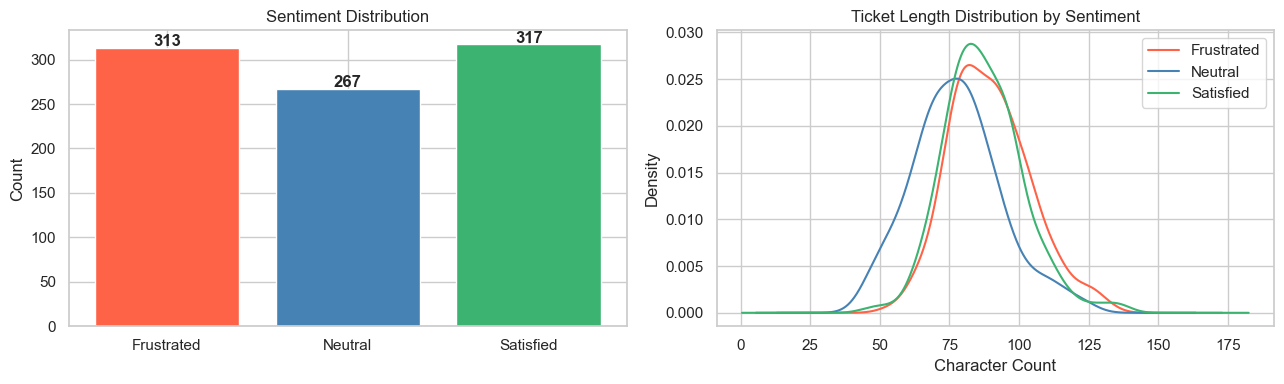


Average ticket length (characters) by sentiment:
sentiment
Frustrated    89.6
Neutral       77.6
Satisfied     87.2


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
axes[0].bar(ORDER, counts.values, color=COLORS)
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Text length distribution by sentiment
df['text_length'] = df['review_text'].str.len()
for sent, color in zip(ORDER, COLORS):
    df[df['sentiment'] == sent]['text_length'].plot(
        kind='kde', ax=axes[1], label=sent, color=color)
axes[1].set_title('Ticket Length Distribution by Sentiment')
axes[1].set_xlabel('Character Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nAverage ticket length (characters) by sentiment:')
print(df.groupby('sentiment')['text_length'].mean().reindex(ORDER).round(1).to_string())

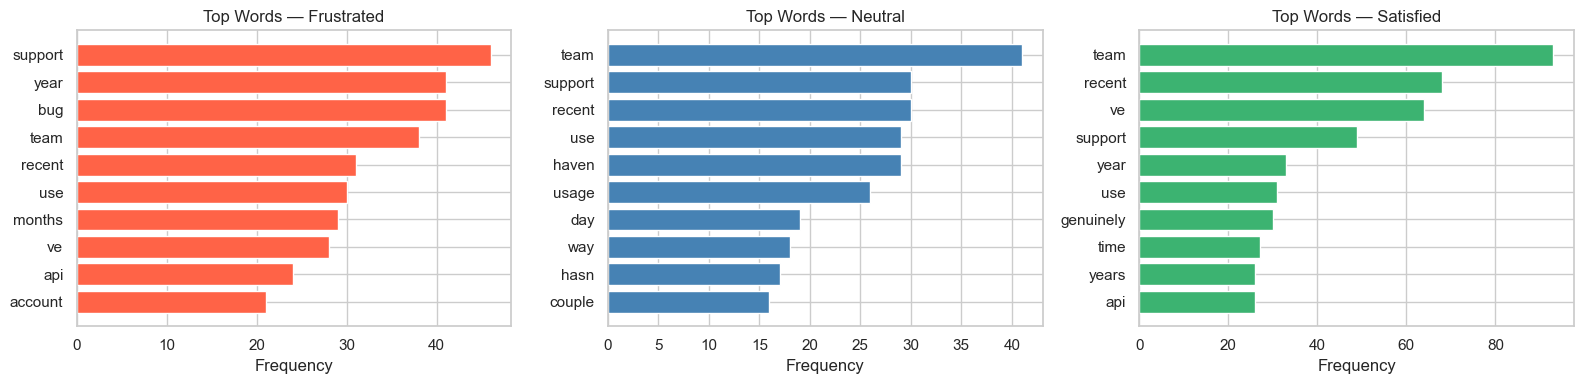

In [6]:
# Top words per sentiment (before stopword removal, CountVectorizer not TF-IDF —
# raw counts are more intuitive to read directly than TF-IDF weights for this display)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, sent, color in zip(axes, ORDER, COLORS):
    subset = df[df['sentiment'] == sent]['review_text']
    cv = CountVectorizer(stop_words='english', max_features=10)
    cv.fit(subset)
    counts_arr = cv.transform(subset).toarray().sum(axis=0)
    words = cv.get_feature_names_out()
    idx = np.argsort(counts_arr)[::-1]
    ax.barh([words[i] for i in idx][::-1], [counts_arr[i] for i in idx][::-1], color=color)
    ax.set_title(f'Top Words — {sent}')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

In [7]:
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

train, temp = train_test_split(
    df, test_size=(1 - TRAIN_FRAC), stratify=df['sentiment'], random_state=SEED
)
val, test = train_test_split(
    temp, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=temp['sentiment'], random_state=SEED
)

train.to_csv('Datasets/train_sentiment.csv', index=False)
val.to_csv('Datasets/validation_sentiment.csv', index=False)
test.to_csv('Datasets/test_sentiment.csv', index=False)

X_train, y_train = train['review_text'], train['sentiment']
X_val,   y_val   = val['review_text'],   val['sentiment']
X_test,  y_test  = test['review_text'],  test['sentiment']

print(f'Train:      {train.shape}  ({len(train)/len(df):.1%})')
print(f'Validation: {val.shape}  ({len(val)/len(df):.1%})')
print(f'Test:       {test.shape}  ({len(test)/len(df):.1%})')
print('\nTrain class balance:', y_train.value_counts().reindex(ORDER).to_dict())
print('Val class balance:  ', y_val.value_counts().reindex(ORDER).to_dict())
print('Test class balance: ', y_test.value_counts().reindex(ORDER).to_dict())

Train:      (627, 3)  (69.9%)
Validation: (135, 3)  (15.1%)
Test:       (135, 3)  (15.1%)

Train class balance: {'Frustrated': 219, 'Neutral': 187, 'Satisfied': 221}
Val class balance:   {'Frustrated': 47, 'Neutral': 40, 'Satisfied': 48}
Test class balance:  {'Frustrated': 47, 'Neutral': 40, 'Satisfied': 48}


In [8]:
# TF-IDF settings shared across all models
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    stop_words='english',
    sublinear_tf=True
)

models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED),
}

In [9]:
pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([('tfidf', tfidf), ('clf', clf)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f'Trained: {name}')

Trained: Logistic Regression


Trained: Naive Bayes
Trained: Linear SVM


Trained: Random Forest


In [10]:
# ── 5-Fold CV on TRAIN only — this decides the winner, not the single-split
# table below. With only 897 tickets total, a single 135-row validation split
# is noisy enough to flip the ranking depending on random_state; averaging
# over 5 folds gives a much more stable read on which architecture actually
# generalizes best. Scoped to X_train/y_train (not the full dataset) so the
# validation and test rows used later in this notebook are never touched by
# the selection process itself.
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_weighted')
    cv_rows.append({
        'Model': name,
        'CV F1 (weighted) mean': round(scores.mean(), 4),
        'CV F1 (weighted) std':  round(scores.std(), 4),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values('CV F1 (weighted) mean', ascending=False)
print('5-Fold Cross-Validation (weighted F1, train only) — this decides the winner:')
cv_results_df

5-Fold Cross-Validation (weighted F1, train only) — this decides the winner:


,Model,CV F1 (weighted) mean,CV F1 (weighted) std
2,Linear SVM,0.6930,0.0367
0,Logistic Regression,0.6739,0.0349
1,Naive Bayes,0.6703,0.0207
3,Random Forest,0.5981,0.0460


In [11]:
# Single-split validation numbers — diagnostic only, NOT what picks the winner
# (see the 5-fold CV cell above for that). Shown here for a quick sanity check
# and because it's still useful context, even though on this run it disagrees
# with the CV ranking (this split favors Naive Bayes; CV favors Linear SVM) —
# exactly the kind of split-to-split noise 5-fold CV exists to average out.
results = []
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_val)
    results.append({
        'Model':         name,
        'Accuracy':      round(accuracy_score(y_val, y_pred), 4),
        'F1 (weighted)': round(f1_score(y_val, y_pred, average='weighted'), 4),
        'F1 (macro)':    round(f1_score(y_val, y_pred, average='macro'), 4),
    })

results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False)
results_df

,Model,Accuracy,F1 (weighted),F1 (macro)
1,Naive Bayes,0.7407,0.7395,0.7384
2,Linear SVM,0.7407,0.7376,0.7350
0,Logistic Regression,0.7111,0.7038,0.7000
3,Random Forest,0.6148,0.6148,0.6149


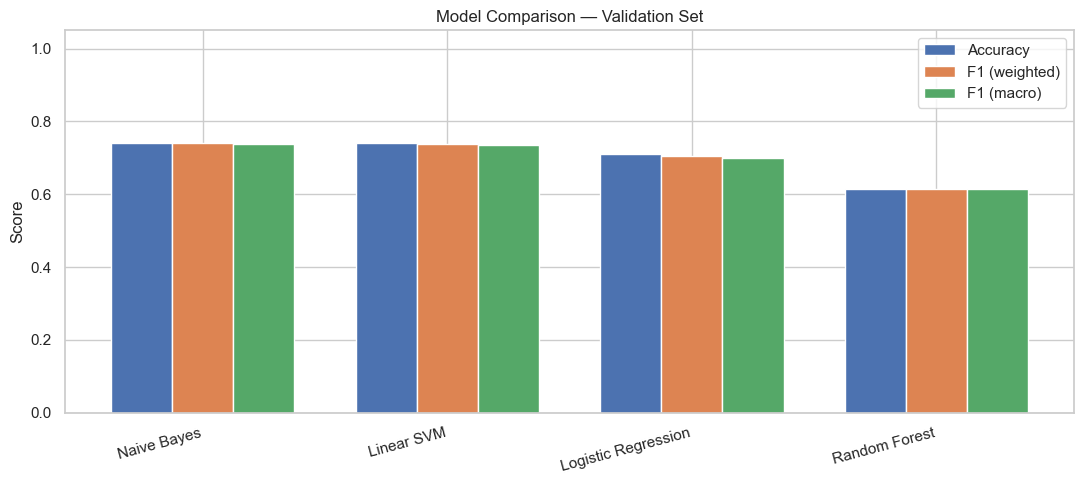

In [12]:
# Bar chart comparison
metrics = ['Accuracy', 'F1 (weighted)', 'F1 (macro)']
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Validation Set')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Winner is chosen by 5-fold CV weighted F1 (train only), not the single-split
# table above — see that cell and the CV cell's comments for why.
best_name = cv_results_df.iloc[0]['Model']
best_pipe = pipelines[best_name]
y_pred = best_pipe.predict(X_test)

print(f'Best model (by 5-fold CV weighted F1, train only): {best_name}')
print('\nClassification Report — Test Set:')
print(classification_report(y_test, y_pred, target_names=ORDER))

Best model (by 5-fold CV weighted F1, train only): Linear SVM

Classification Report — Test Set:
              precision    recall  f1-score   support

  Frustrated       0.80      0.74      0.77        47
     Neutral       0.77      0.68      0.72        40
   Satisfied       0.70      0.81      0.75        48

    accuracy                           0.75       135
   macro avg       0.75      0.74      0.75       135
weighted avg       0.75      0.75      0.75       135



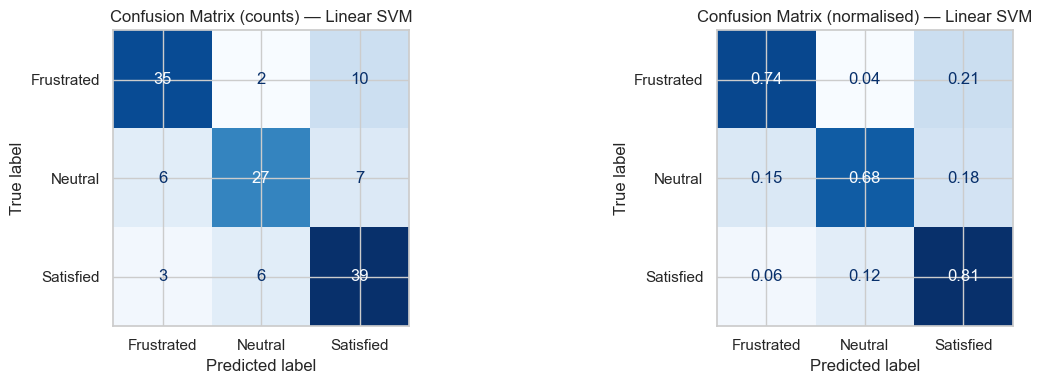

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=ORDER)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=ORDER).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (counts) — {best_name}')

# Normalised (row-wise: recall per true class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=ORDER).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix (normalised) — {best_name}')

plt.tight_layout()
plt.show()

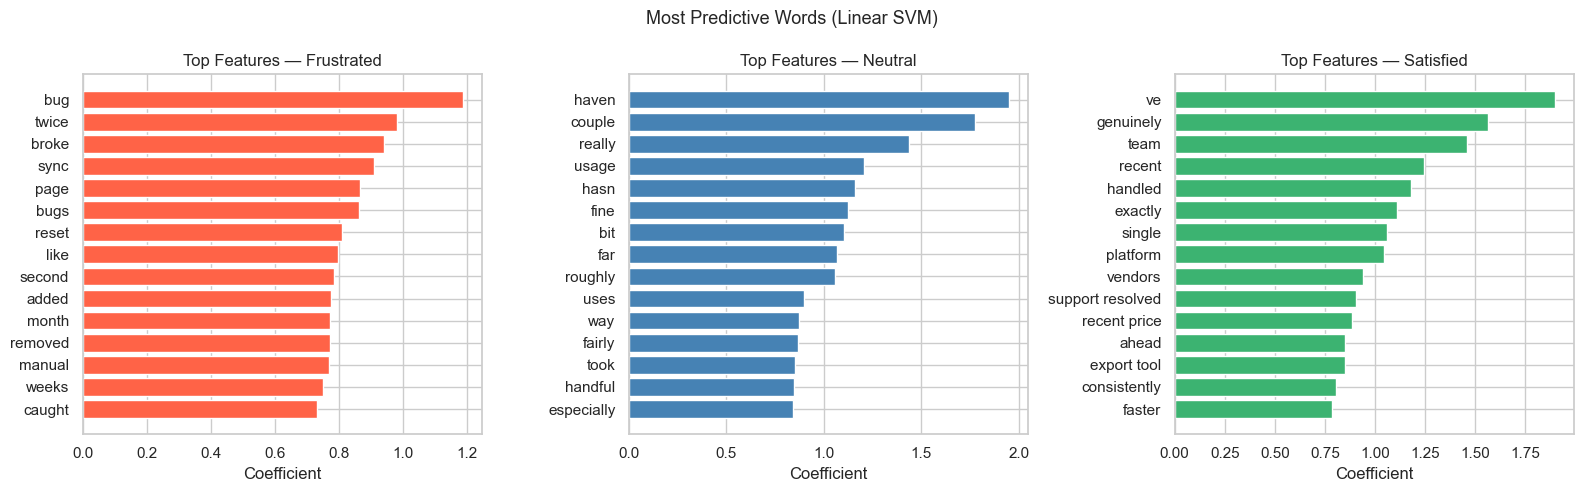

In [15]:
clf = best_pipe.named_steps['clf']
vec = best_pipe.named_steps['tfidf']
feature_names = vec.get_feature_names_out()

if hasattr(clf, 'coef_'):
    # Logistic Regression / Linear SVM — one coefficient vector per class
    classes, weights, kind = clf.classes_, clf.coef_, 'Coefficient'
elif hasattr(clf, 'feature_log_prob_'):
    # Multinomial Naive Bayes — log P(word | class) per class
    classes, weights, kind = clf.classes_, clf.feature_log_prob_, 'Log P(word | class)'
else:
    classes, weights, kind = None, None, None

if weights is not None:
    fig, axes = plt.subplots(1, len(classes), figsize=(16, 5))
    for ax, cls, color in zip(axes, classes, COLORS):
        row = weights[list(classes).index(cls)]
        top_idx = np.argsort(row)[-15:][::-1]
        ax.barh([feature_names[i] for i in top_idx][::-1],
                [row[i] for i in top_idx][::-1], color=color)
        ax.set_title(f'Top Features — {cls}')
        ax.set_xlabel(kind)
    plt.suptitle(f'Most Predictive Words ({best_name})', fontsize=13)
    plt.tight_layout()
    plt.show()
elif hasattr(clf, 'feature_importances_'):
    # Random Forest — one global importance per word, not per class
    top_idx = np.argsort(clf.feature_importances_)[-20:][::-1]
    plt.figure(figsize=(9, 5))
    plt.barh([feature_names[i] for i in top_idx][::-1],
             clf.feature_importances_[top_idx][::-1], color='steelblue')
    plt.title(f'Top 20 Features (global) — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not available for this model type.')

In [16]:
sample_tickets = [
    "I've been waiting three days for a response and this is still not resolved.",
    "How do I export my data as a CSV from the reports section?",
    "Just wanted to say the new dashboard update is fantastic. Really clean.",
    "The API keeps returning 500 errors and our integration is completely broken.",
    "Can I add two admins to the same workspace?",
    "Your support team resolved my issue in under an hour. Brilliant service.",
]

preds = best_pipe.predict(sample_tickets)
for ticket, pred in zip(sample_tickets, preds):
    print(f'[{pred:<12}]  {ticket}')

[Neutral     ]  I've been waiting three days for a response and this is still not resolved.
[Frustrated  ]  How do I export my data as a CSV from the reports section?
[Neutral     ]  Just wanted to say the new dashboard update is fantastic. Really clean.
[Frustrated  ]  The API keeps returning 500 errors and our integration is completely broken.
[Neutral     ]  Can I add two admins to the same workspace?
[Neutral     ]  Your support team resolved my issue in under an hour. Brilliant service.


In [17]:
test_out = test.copy()
test_out['Predicted_Sentiment'] = y_pred
test_out['Correct'] = test_out['sentiment'] == test_out['Predicted_Sentiment']

if hasattr(best_pipe, 'predict_proba'):
    proba = best_pipe.predict_proba(X_test)
    for i, cls in enumerate(best_pipe.classes_):
        test_out[f'P({cls})'] = proba[:, i].round(4)

test_out.to_csv('Datasets/test_sentiment_predictions.csv', index=False)
print('Saved → Datasets/test_sentiment_predictions.csv')
test_out.drop(columns=['text_length'], errors='ignore').head(10)

Saved → Datasets/test_sentiment_predictions.csv


,review_text,sentiment,Predicted_Sentiment,Correct
785,"One data export ran into an issue, resolved af...",Neutral,Satisfied,False
44,We're comfortable with the current setup and h...,Neutral,Neutral,True
88,Nobody flagged the missing columns in the expo...,Frustrated,Frustrated,True
110,We've recommended this to two partner companie...,Satisfied,Satisfied,True
527,We're evaluating whether to expand usage to an...,Neutral,Neutral,True
390,A routine maintenance window caused a short de...,Neutral,Neutral,True
90,The recent feature rollout was communicated cl...,Satisfied,Satisfied,True
368,It's been about what we expected going into th...,Neutral,Neutral,True
442,Renewal terms this year quietly dropped a feat...,Frustrated,Frustrated,True
846,"The export feature works, though we occasional...",Neutral,Frustrated,False


In [18]:
os.makedirs('models', exist_ok=True)

# Save best model
model_path = f'models/sentiment_{best_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_pipe, model_path)
print(f'Best model saved → {model_path}')

# Save all trained pipelines
for name, pipe in pipelines.items():
    path = f'models/sentiment_{name.lower().replace(" ", "_")}.pkl'
    joblib.dump(pipe, path)
    print(f'Saved → {path}')

Best model saved → models/sentiment_linear_svm.pkl


Saved → models/sentiment_logistic_regression.pkl
Saved → models/sentiment_naive_bayes.pkl


Saved → models/sentiment_linear_svm.pkl


Saved → models/sentiment_random_forest.pkl

In [19]:
# Verify: reload best model and confirm predictions are identical
loaded_model = joblib.load(model_path)
assert (loaded_model.predict(X_test) == best_pipe.predict(X_test)).all(), 'Mismatch after reload!'
print('Verification passed — reloaded model predictions match original.')
print(f'Model ready to use: {model_path}')

Verification passed — reloaded model predictions match original.
Model ready to use: models/sentiment_linear_svm.pkl
